<a href="https://colab.research.google.com/github/Dani-dong/Seoul-Bike/blob/main/%EB%AF%B8%EB%8B%88_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ━━━━ 매번 맨 처음에 실행 ━━━━

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 나눔 폰트 설치 및 설정
!apt-get -qq install fonts-nanum

# 폰트 캐시 삭제 (한글 깨짐 방지 핵심)
!rm -rf ~/.cache/matplotlib

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic'})
plt.rcParams['axes.unicode_minus'] = False

PATH = '/content/drive/MyDrive/Colab Notebooks/04.14 실습_data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv(PATH + '따릉이_분석용.csv', encoding='utf-8')
# 한글 깨지면 encoding='euc-kr' 또는 'utf-8' 시도

print(f'데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열')

데이터 크기: 13,795행 × 8열


In [3]:
df.head()

,자치구,대여소명,기준년월,대여건수,반납건수,위도,경도,거치대수
0,마포구,108. 서교동 사거리,202507,1277,1314,37.544582,127.044609,10.0
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808,37.481491,126.981583,NaN
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218,37.486835,126.968048,NaN
3,양천구,733. 신정이펜하우스314동,202507,876,375,37.494499,126.916527,NaN
4,양천구,734. 신트리공원 입구,202507,2987,2958,37.688274,127.049065,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13795 entries, 0 to 13794
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   자치구     13795 non-null  object 
 1   대여소명    13795 non-null  object 
 2   기준년월    13795 non-null  int64  
 3   대여건수    13795 non-null  int64  
 4   반납건수    13795 non-null  int64  
 5   위도      9030 non-null   float64
 6   경도      9030 non-null   float64
 7   거치대수    8532 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 862.3+ KB


In [5]:
df.columns

Index(['자치구', '대여소명', '기준년월', '대여건수', '반납건수', '위도', '경도', '거치대수'], dtype='object')

In [6]:
print(df.shape)
# 또는
print(f'{len(df):,}개 대여소')

(13795, 8)
13,795개 대여소


In [7]:
df.head(10)

,자치구,대여소명,기준년월,대여건수,반납건수,위도,경도,거치대수
0,마포구,108. 서교동 사거리,202507,1277,1314,37.544582,127.044609,10.0
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808,37.481491,126.981583,NaN
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218,37.486835,126.968048,NaN
3,양천구,733. 신정이펜하우스314동,202507,876,375,37.494499,126.916527,NaN
4,양천구,734. 신트리공원 입구,202507,2987,2958,37.688274,127.049065,NaN
5,양천구,735. 영도초등학교,202507,2687,3038,37.626614,127.072754,NaN
6,양천구,736. 오솔길공원,202507,1069,1179,37.649021,127.076408,NaN
7,양천구,737. 장수공원,202507,717,571,37.493729,127.120621,NaN
8,양천구,739. 신월사거리,202507,950,960,37.512104,127.107780,NaN
9,양천구,740. 으뜸공원,202507,1076,1322,37.502594,127.127647,NaN


In [8]:
df.isnull().sum()

,0
자치구,0
대여소명,0
기준년월,0
대여건수,0
반납건수,0
위도,4765
경도,4765
거치대수,5263


In [9]:
df.nlargest(5, '대여건수')[['대여소명', '자치구', '대여건수']]
# 또는
df.sort_values('대여건수', ascending=False).head(5)[['대여소명', '자치구', '대여건수']]

,대여소명,자치구,대여건수
6383,2715.마곡나루역 2번 출구,강서구,17664
889,2715.마곡나루역 2번 출구,강서구,15460
3633,2715.마곡나루역 2번 출구,강서구,15117
9140,2715.마곡나루역 2번 출구,강서구,14782
11906,2715.마곡나루역 2번 출구,강서구,14217


In [10]:
영등포 = df[df['자치구'] == '영등포구']
print(f'영등포구 대여소: {len(영등포)}개')

영등포구 대여소: 849개


In [11]:
거치대없음 = df[df['거치대수'] == 0]
print(f'{len(거치대없음)}개')
거치대없음[['대여소명', '자치구']]

0개


,대여소명,자치구


In [13]:
df.groupby('자치구').size().sort_values(ascending=False)
# 또는
df['자치구'].value_counts()

,count
자치구,
송파구,1096
강서구,966
강남구,851
영등포구,849
노원구,755
서초구,723
마포구,601
강동구,601
구로구,574


In [14]:
gu_rent = df.groupby('자치구')['대여건수'].sum().sort_values(ascending=False)
print(gu_rent)
print(f'\n1위: {gu_rent.index[0]} ({gu_rent.iloc[0]:,}건)')

자치구
강서구     2200391
송파구     1644794
영등포구    1630819
양천구     1095806
노원구     1046746
강동구      844581
마포구      838684
광진구      838194
구로구      725741
성동구      656857
강남구      611453
동대문구     582291
종로구      569590
서초구      535191
중랑구      478850
중구       418676
은평구      404271
도봉구      371256
성북구      356768
용산구      350394
관악구      345402
서대문구     321144
동작구      306411
금천구      291549
강북구      216729
Name: 대여건수, dtype: int64

1위: 강서구 (2,200,391건)


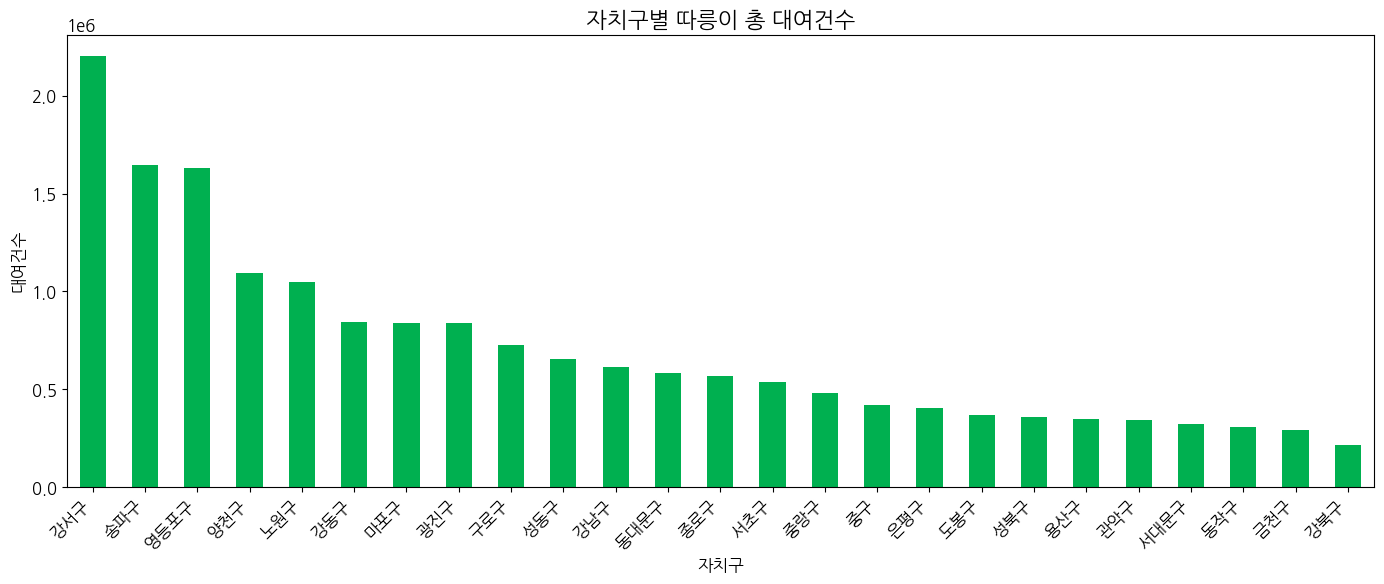

In [15]:
import matplotlib.pyplot as plt

# 이미 첫 번째 셀에서 설정했으므로 바로 그립니다.
gu_rent = df.groupby('자치구')['대여건수'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
gu_rent.plot(kind='bar', color='#00B050')
plt.title('자치구별 따릉이 총 대여건수', fontsize=16)
plt.xlabel('자치구')
plt.ylabel('대여건수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
gu_balance = df.groupby('자치구').agg(
    총대여=('대여건수', 'sum'),
    총반납=('반납건수', 'sum')
).reset_index()

gu_balance['차이'] = gu_balance['총대여'] - gu_balance['총반납']

print(gu_balance.sort_values('차이', ascending=False))

     자치구      총대여      총반납     차이
22   종로구   569590   544650  24940
0    강남구   611453   586722  24731
19  영등포구  1630819  1608719  22100
23    중구   418676   400111  18565
5    광진구   838194   824573  13621
13  서대문구   321144   308351  12793
3    강서구  2200391  2191002   9389
17   송파구  1644794  1638586   6208
14   서초구   535191   529950   5241
20   용산구   350394   345910   4484
4    관악구   345402   341729   3673
2    강북구   216729   213422   3307
6    구로구   725741   723587   2154
9    도봉구   371256   370722    534
7    금천구   291549   291172    377
12   마포구   838684   838362    322
8    노원구  1046746  1046468    278
16   성북구   356768   358528  -1760
11   동작구   306411   308937  -2526
15   성동구   656857   661320  -4463
24   중랑구   478850   484639  -5789
1    강동구   844581   851717  -7136
18   양천구  1095806  1103111  -7305
21   은평구   404271   415561 -11290
10  동대문구   582291   599080 -16789


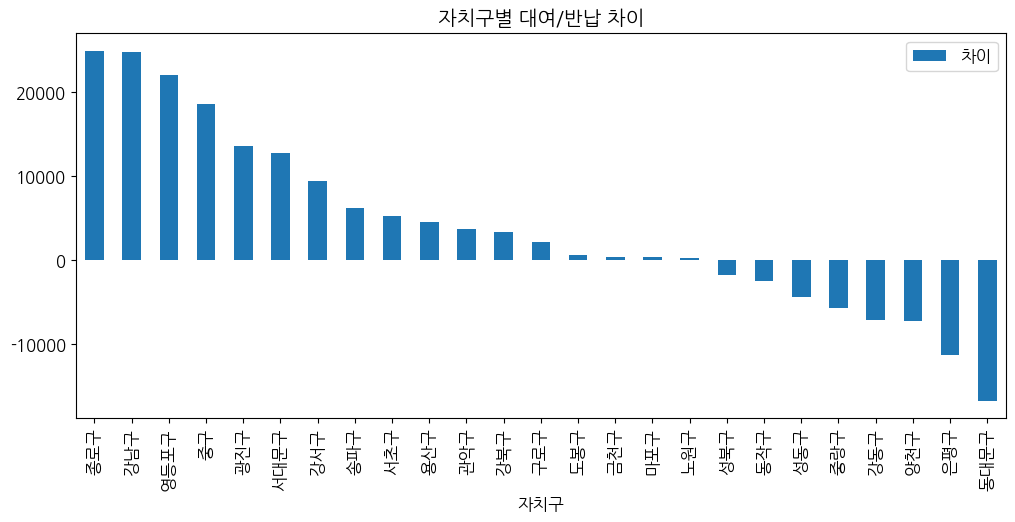

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔 폰트 설치
!apt-get -qq install fonts-nanum

# 폰트 설정
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic'})
plt.rcParams['axes.unicode_minus'] = False

# 설정 확인을 위한 테스트 출력
gu_balance = df.groupby('자치구').agg(
    총대여=('대여건수', 'sum'),
    총반납=('반납건수', 'sum')
).reset_index()

gu_balance['차이'] = gu_balance['총대여'] - gu_balance['총반납']

# 시각화 테스트
gu_balance.sort_values('차이', ascending=False).plot(kind='bar', x='자치구', y='차이', figsize=(12, 5))
plt.title('자치구별 대여/반납 차이')
plt.show()

In [ ]:
# 런타임 재시작이 필요한 경우 아래 코드를 실행하세요.
# 실행 후에는 첫 번째 셀부터 다시 실행해야 합니다.
import os
os.kill(os.getpid(), 9)

In [18]:
df_t = pd.read_csv(PATH + '따릉이_고장신고 내역.csv', encoding='euc-kr')
# 한글 깨지면 encoding='euc-kr' 또는 'utf-8' 시도

print(f'데이터 크기: {df_t.shape[0]:,}행 × {df_t.shape[1]}열')

데이터 크기: 59,305행 × 3열


### 가설 검증: 고장 신고와 대여 건수의 관계 분석
**가설**: 고장 신고가 빈번한 대여소는 서비스 품질 저하로 인해 대여 건수가 적을 것이다.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 고장 신고 데이터(df_t)에서 대여소별 고장 건수 집계가 필요한데,
# df_t에 '대여소명' 또는 '대여소번호'가 있는지 확인이 필요합니다.
# 만약 df_t에 대여소 정보가 없다면 분석이 어려우므로, df_t의 컬럼을 다시 확인합니다.
print("df_t 컬럼 목록:", df_t.columns.tolist())
display(df_t.head())

df_t 컬럼 목록: ['자전거번호', '등록일시', '구분']


,자전거번호,등록일시,구분
0,SPB-72175,2025-07-01 00:08:14,기타
1,SPB-52313,2025-07-01 00:27:42,기타
2,SPB-68508,2025-07-01 00:34:17,체인
3,SPB-46541,2025-07-01 00:43:50,타이어
4,SPB-46541,2025-07-01 00:43:50,안장


일반적으로 따릉이 고장 데이터에는 대여소 정보가 포함되지 않는 경우가 많습니다. 만약 `df_t`에 대여소 정보가 있다면 아래 코드를 실행하여 분석을 진행할 수 있습니다. (여기서는 `df_t`에 '대여소번호'나 '대여소명'이 있다고 가정하고 예시 코드를 작성합니다.)

In [23]:
# 2. 대여소별 고장 건수 집계 (예시: df_t에 '대여소' 관련 컬럼이 있다고 가정)
# 실제 데이터에 맞춰 '대여소명' 부분을 수정해야 할 수 있습니다.
if '대여소명' in df_t.columns:
    fault_counts = df_t.groupby('대여소명').size().reset_index(name='고장건수')

    # 3. 데이터 병합 (df와 fault_counts)
    merged_df = pd.merge(df, fault_counts, on='대여소명', how='left')
    merged_df['고장건수'] = merged_df['고장건수'].fillna(0)

    # 4. 시각화 및 상관계수
    correlation = merged_df[['대여건수', '고장건수']].corr().iloc[0, 1]
    print(f"대여건수와 고장건수 간의 상관계수: {correlation:.4f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=merged_df, x='고장건수', y='대여건수', alpha=0.5)
    plt.title(f'고장건수 대비 대여건수 분포 (상관계수: {correlation:.2f})')
    plt.xlabel('고장 신고 건수')
    plt.ylabel('대여 건수')
    plt.grid(True)
    plt.show()
else:
    print("df_t 데이터에 대여소 정보가 없어 직접적인 Join이 불가능합니다. 자전거 번호별 분석 등 다른 접근이 필요할 수 있습니다.")

df_t 데이터에 대여소 정보가 없어 직접적인 Join이 불가능합니다. 자전거 번호별 분석 등 다른 접근이 필요할 수 있습니다.


In [21]:
df.columns

Index(['자치구', '대여소명', '기준년월', '대여건수', '반납건수', '위도', '경도', '거치대수'], dtype='object')

### 가설 검증: 대여소명에 '역'이 포함된 곳은 대여/반납 차이가 클 것이다
**가설**: 지하철역 인근 대여소('역' 포함)는 출퇴근 등 특정 시간대 쏠림 현상으로 인해 대여와 반납의 불균형(차이)이 더 크게 나타날 것이다.

,역세권여부,대여반납차이
0,비역세권,95.894174
1,역세권,119.928760


/tmp/ipykernel_13972/1767294409.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=station_analysis, x='역세권여부', y='대여반납차이', palette='Set2')


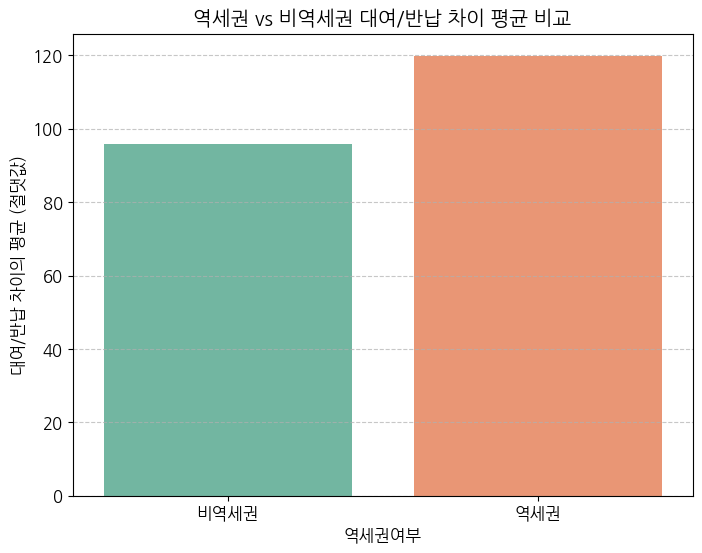

역세권 대여반납차이 평균: 119.93
비역세권 대여반납차이 평균: 95.89
P-value: 0.0000
결론: 통계적으로 유의미한 차이가 있습니다. 가설이 지지됩니다.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 대여/반납 차이 계산 (이미 df에 '차이'가 없다면 계산)
df['대여반납차이'] = (df['대여건수'] - df['반납건수']).abs()

# 2. '역' 포함 여부 컬럼 생성
df['역세권여부'] = df['대여소명'].str.contains('역').map({True: '역세권', False: '비역세권'})

# 3. 그룹별 평균 차이 계산
station_analysis = df.groupby('역세권여부')['대여반납차이'].mean().reset_index()
display(station_analysis)

# 4. 시각화
plt.figure(figsize=(8, 6))
sns.barplot(data=station_analysis, x='역세권여부', y='대여반납차이', palette='Set2')
plt.title('역세권 vs 비역세권 대여/반납 차이 평균 비교')
plt.ylabel('대여/반납 차이의 평균 (절댓값)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# T-test 등을 통한 통계적 유의성 확인 (선택 사항)
from scipy import stats
station_group = df[df['역세권여부'] == '역세권']['대여반납차이']
non_station_group = df[df['역세권여부'] == '비역세권']['대여반납차이']
t_stat, p_val = stats.ttest_ind(station_group, non_station_group)

print(f"역세권 대여반납차이 평균: {station_group.mean():.2f}")
print(f"비역세권 대여반납차이 평균: {non_station_group.mean():.2f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("결론: 통계적으로 유의미한 차이가 있습니다. 가설이 지지됩니다.")
else:
    print("결론: 통계적으로 유의미한 차이가 없습니다. 가설을 기각합니다.")